# Solar Panel Fault Detection — Universal Training & Evaluation
# Capacity-Agnostic Version: models trained on normalized features.
# These models work on ANY solar station regardless of MW capacity.
# Input: faulted_dataset_universal.csv (from solar_data_pipeline_universal.ipynb)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import subprocess, sys

REQUIRED_PACKAGES = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
    'xgboost', 'lightgbm', 'catboost', 'joblib', 'tqdm',
]

def install_missing_packages():
    for pkg in REQUIRED_PACKAGES:
        pkg_import = pkg.replace('-', '_')
        if pkg == 'scikit-learn': pkg_import = 'sklearn'
        try:
            __import__(pkg_import)
        except ImportError:
            print(f"[INSTALL] Installing {pkg}...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install_missing_packages()
print("All packages ready.")


[INSTALL] Installing catboost...
All packages ready.


In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, json
from collections import Counter
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

print("Libraries imported successfully.")


Libraries imported successfully.


In [4]:
# ================================================================
# CONFIGURATION — must match what was used in the pipeline notebook
# ================================================================
CONFIG = {
    'DATA_DIR'  : '/content/drive/MyDrive/SolarGard4/solar_data',
    'MODEL_DIR' : '/content/drive/MyDrive/SolarGard4/solar_models_universal',
    'FAULT_LABELS': {
        0: 'Normal',            1: 'Partial Shading',
        2: 'Soiling',           3: 'Degradation',
        4: 'Inverter Fault',    5: 'Open-Circuit String',
        6: 'Short-Circuit',     7: 'Sensor Fault',
    },
}

# 27 Universal (normalized) feature columns
FEATURE_COLS = [
    # Normalized power & electrical (capacity-agnostic)
    "NORM_DC_POWER", "NORM_AC_POWER",
    "NORM_DC_VOLTAGE", "NORM_DC_CURRENT",
    "NORM_POWER_VOLATILITY", "NORM_CURRENT_IMBALANCE", "NORM_VOLTAGE_SPREAD",
    # Ratio & efficiency (already universal)
    "DC_AC_RATIO", "EFFICIENCY", "PERFORMANCE_RATIO", "DC_AC_DEV",
    # Temperature (universal)
    "AMBIENT_TEMP", "MODULE_TEMP", "TEMP_COEFF",
    "TEMP_DIFFERENCE", "TEMP_DEV", "WIND_SPEED",
    # Irradiance & sky (universal)
    "IRRADIATION", "CLEARNESS_INDEX", "DIFFUSE_RATIO",
    "CLOUD_COVER_EST", "SKY_TEMP_EST",
    # Solar geometry (universal)
    "ZENITH_ANGLE", "AZIMUTH_ANGLE",
    # Time (universal)
    "HOUR", "DAY_OF_YEAR", "MONTH",
]
# Deduplicate while preserving order
seen = set()
FEATURE_COLS = [f for f in FEATURE_COLS if f not in seen and not seen.add(f)]
FEATURE_COLS = FEATURE_COLS[:29]

os.makedirs(CONFIG['MODEL_DIR'], exist_ok=True)

print('=' * 60)
print('  SOLAR FAULT DETECTION — UNIVERSAL TRAINING')
print('=' * 60)
print(f"  Dataset    : faulted_dataset_universal.csv")
print(f"  Features   : {len(FEATURE_COLS)} normalized features")
print(f"  Models     : LightGBM, XGBoost, CatBoost")
print(f"  Output dir : {CONFIG['MODEL_DIR']}")
print('=' * 60)


  SOLAR FAULT DETECTION — UNIVERSAL TRAINING
  Dataset    : faulted_dataset_universal.csv
  Features   : 27 normalized features
  Models     : LightGBM, XGBoost, CatBoost
  Output dir : /content/drive/MyDrive/SolarGard4/solar_models_universal


## Step 1 — Load & Validate Dataset

In [5]:
dataset_path = os.path.join(CONFIG['DATA_DIR'], 'faulted_dataset_universal.csv')
print(f"Loading: {dataset_path}")
df = pd.read_csv(dataset_path)
print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")

# Validate features
missing_features = [f for f in FEATURE_COLS if f not in df.columns]
if missing_features:
    print(f"[WARN] Features missing from dataset (will fill with 0): {missing_features}")
    for f in missing_features:
        df[f] = 0
else:
    print(f"[OK] All {len(FEATURE_COLS)} universal features present.")

# Target column
if 'fault_label' not in df.columns:
    raise ValueError("'fault_label' column not found in dataset!")

print(f"\nClass distribution:")
dist = df['fault_label'].value_counts().sort_index()
for label, count in dist.items():
    name = CONFIG['FAULT_LABELS'].get(label, f"F{label}")
    pct  = count / len(df) * 100
    print(f"  F{label} ({name:<22s}): {count:7,}  ({pct:5.1f}%)")


Loading: /content/drive/MyDrive/SolarGard4/solar_data/faulted_dataset_universal.csv
Loaded: 80,941 rows × 181 columns
[OK] All 27 universal features present.

Class distribution:
  F0 (Normal                ):  10,122  ( 12.5%)
  F1 (Partial Shading       ):  10,117  ( 12.5%)
  F2 (Soiling               ):  10,117  ( 12.5%)
  F3 (Degradation           ):  10,117  ( 12.5%)
  F4 (Inverter Fault        ):  10,117  ( 12.5%)
  F5 (Open-Circuit String   ):  10,117  ( 12.5%)
  F6 (Short-Circuit         ):  10,117  ( 12.5%)
  F7 (Sensor Fault          ):  10,117  ( 12.5%)


## Step 2 — Feature Value Distribution (Universal Check)

In [6]:
print("Verifying normalized features are in expected [0, ~1] range:")
for feat in [f for f in FEATURE_COLS if f.startswith("NORM_")]:
    min_v = df[feat].min()
    max_v = df[feat].max()
    mean_v= df[feat].mean()
    status = "OK" if max_v <= 2.0 else "WARNING: value > 2.0"
    print(f"  {feat:<30s}: min={min_v:.4f}, mean={mean_v:.4f}, max={max_v:.4f}  [{status}]")

print("\nPer-fault normalized DC Power (should differ clearly between faults):")
for fault in range(8):
    subset = df[df['fault_label'] == fault]
    name   = CONFIG['FAULT_LABELS'].get(fault, f'F{fault}')
    if len(subset) > 0:
        print(f"  F{fault} {name:<22s}: NORM_DC_POWER mean={subset['NORM_DC_POWER'].mean():.3f}")


Verifying normalized features are in expected [0, ~1] range:
  NORM_DC_POWER                 : min=0.0154, mean=0.3714, max=0.8169  [OK]
  NORM_AC_POWER                 : min=0.0057, mean=0.3453, max=0.8371  [OK]
  NORM_DC_VOLTAGE               : min=0.0017, mean=0.0548, max=0.0732  [OK]
  NORM_DC_CURRENT               : min=0.2951, mean=1.8884, max=2.0000  [OK]
  NORM_POWER_VOLATILITY         : min=0.0000, mean=0.0547, max=0.7894  [OK]
  NORM_CURRENT_IMBALANCE        : min=0.0000, mean=0.6943, max=1.0000  [OK]
  NORM_VOLTAGE_SPREAD           : min=0.0000, mean=0.0293, max=0.3000  [OK]

Per-fault normalized DC Power (should differ clearly between faults):
  F0 Normal                : NORM_DC_POWER mean=0.436
  F1 Partial Shading       : NORM_DC_POWER mean=0.364
  F2 Soiling               : NORM_DC_POWER mean=0.357
  F3 Degradation           : NORM_DC_POWER mean=0.410
  F4 Inverter Fault        : NORM_DC_POWER mean=0.436
  F5 Open-Circuit String   : NORM_DC_POWER mean=0.280
  F6 Short-C

## Step 3 — Train/Test Split

In [7]:
X = df[FEATURE_COLS].values
y = df['fault_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} rows")
print(f"Test set     : {len(X_test):,} rows")
print(f"Feature dims : {X_train.shape[1]}")


Training set : 64,752 rows
Test set     : 16,189 rows
Feature dims : 27


## Step 4 — LightGBM (Universal)

In [8]:
print("Training LightGBM...")

lgb_params = {
    'objective'       : 'multiclass',
    'num_class'       : 8,
    'metric'          : 'multi_logloss',
    'learning_rate'   : 0.05,
    'n_estimators'    : 500,
    'num_leaves'      : 63,
    'max_depth'       : 8,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'lambda_l1'       : 0.1,
    'lambda_l2'       : 0.1,
    'verbose'         : -1,
    'random_state'    : 42,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict(X_test)
lgb_acc   = accuracy_score(y_test, lgb_preds)
lgb_f1    = f1_score(y_test, lgb_preds, average='weighted')

print(f"\nLightGBM Results:")
print(f"  Accuracy  : {lgb_acc*100:.2f}%")
print(f"  F1 Score  : {lgb_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lgb_preds,
      target_names=[CONFIG['FAULT_LABELS'][i] for i in range(8)]))


Training LightGBM...
[100]	valid_0's multi_logloss: 0.413225
[200]	valid_0's multi_logloss: 0.369863
[300]	valid_0's multi_logloss: 0.358037
[400]	valid_0's multi_logloss: 0.354636
[500]	valid_0's multi_logloss: 0.353334

LightGBM Results:
  Accuracy  : 85.89%
  F1 Score  : 85.98%

Classification Report:
                     precision    recall  f1-score   support

             Normal       0.69      0.69      0.69      2025
    Partial Shading       1.00      1.00      1.00      2023
            Soiling       0.73      0.75      0.74      2023
        Degradation       0.66      0.68      0.67      2023
     Inverter Fault       1.00      1.00      1.00      2024
Open-Circuit String       0.83      0.88      0.85      2024
      Short-Circuit       1.00      1.00      1.00      2023
       Sensor Fault       0.99      0.88      0.93      2024

           accuracy                           0.86     16189
          macro avg       0.86      0.86      0.86     16189
       weighted avg  

## Step 5 — XGBoost (Universal)

In [9]:
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    objective        = 'multi:softprob',
    num_class        = 8,
    learning_rate    = 0.05,
    n_estimators     = 500,
    max_depth        = 7,
    min_child_weight = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    eval_metric      = 'mlogloss',
    early_stopping_rounds = 50,
    verbosity        = 0,
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=100)

xgb_preds = xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_f1    = f1_score(y_test, xgb_preds, average='weighted')

print(f"\nXGBoost Results:")
print(f"  Accuracy  : {xgb_acc*100:.2f}%")
print(f"  F1 Score  : {xgb_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=[CONFIG['FAULT_LABELS'][i] for i in range(8)]))


Training XGBoost...
[0]	validation_0-mlogloss:1.96368
[100]	validation_0-mlogloss:0.51561
[200]	validation_0-mlogloss:0.41427
[300]	validation_0-mlogloss:0.38446
[400]	validation_0-mlogloss:0.37006
[499]	validation_0-mlogloss:0.36228

XGBoost Results:
  Accuracy  : 85.40%
  F1 Score  : 85.48%

Classification Report:
                     precision    recall  f1-score   support

             Normal       0.69      0.67      0.68      2025
    Partial Shading       1.00      1.00      1.00      2023
            Soiling       0.72      0.74      0.73      2023
        Degradation       0.65      0.67      0.66      2023
     Inverter Fault       1.00      1.00      1.00      2024
Open-Circuit String       0.81      0.89      0.85      2024
      Short-Circuit       1.00      1.00      1.00      2023
       Sensor Fault       0.99      0.87      0.92      2024

           accuracy                           0.85     16189
          macro avg       0.86      0.85      0.85     16189
       we

## Step 6 — CatBoost (Universal)

In [10]:
print("Training CatBoost...")

cb_model = CatBoostClassifier(
    iterations        = 500,
    learning_rate     = 0.05,
    depth             = 8,
    l2_leaf_reg       = 3,
    random_seed       = 42,
    loss_function     = 'MultiClass',
    eval_metric       = 'Accuracy',
    early_stopping_rounds = 50,
    verbose           = 100,
)

cb_model.fit(X_train, y_train,
             eval_set=(X_test, y_test),
             use_best_model=True)

cb_preds = cb_model.predict(X_test).flatten()
cb_acc   = accuracy_score(y_test, cb_preds)
cb_f1    = f1_score(y_test, cb_preds, average='weighted')

print(f"\nCatBoost Results:")
print(f"  Accuracy  : {cb_acc*100:.2f}%")
print(f"  F1 Score  : {cb_f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, cb_preds,
      target_names=[CONFIG['FAULT_LABELS'][i] for i in range(8)]))


Training CatBoost...
0:	learn: 0.6477638	test: 0.6476620	best: 0.6476620 (0)	total: 466ms	remaining: 3m 52s
100:	learn: 0.7896590	test: 0.7802829	best: 0.7802829 (100)	total: 47.8s	remaining: 3m 8s
200:	learn: 0.8221213	test: 0.8098709	best: 0.8098709 (200)	total: 1m 34s	remaining: 2m 21s
300:	learn: 0.8440666	test: 0.8217308	best: 0.8223485 (299)	total: 2m 23s	remaining: 1m 34s
400:	learn: 0.8601896	test: 0.8313052	best: 0.8313052 (398)	total: 3m 11s	remaining: 47.4s
499:	learn: 0.8715715	test: 0.8351350	best: 0.8351350 (499)	total: 3m 58s	remaining: 0us

bestTest = 0.8351349682
bestIteration = 499


CatBoost Results:
  Accuracy  : 83.51%
  F1 Score  : 83.58%

Classification Report:
                     precision    recall  f1-score   support

             Normal       0.67      0.63      0.65      2025
    Partial Shading       0.99      1.00      1.00      2023
            Soiling       0.70      0.70      0.70      2023
        Degradation       0.63      0.66      0.64      2023
 

## Step 7 — Model Comparison

  UNIVERSAL MODEL COMPARISON SUMMARY
  Model          Accuracy   F1 Score
--------------------------------------------------
  LightGBM         85.89%     85.98% <-- BEST
  XGBoost          85.40%     85.48%
  CatBoost         83.51%     83.58%
  Best model: LightGBM


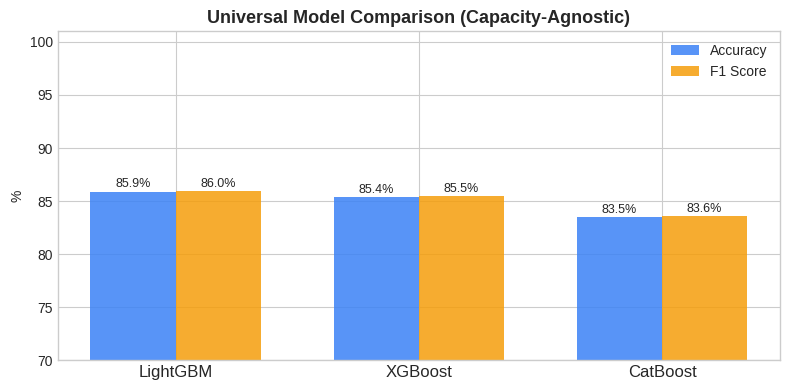

In [11]:
results = {
    'LightGBM': {'accuracy': lgb_acc, 'f1': lgb_f1, 'model': lgb_model},
    'XGBoost' : {'accuracy': xgb_acc, 'f1': xgb_f1, 'model': xgb_model},
    'CatBoost': {'accuracy': cb_acc,  'f1': cb_f1,  'model': cb_model},
}

print("=" * 50)
print("  UNIVERSAL MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"  {'Model':<12} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 50)
best_model_name = None
best_f1 = -1
for name, r in results.items():
    marker = " <-- BEST" if r['f1'] > best_f1 else ""
    if r['f1'] > best_f1:
        best_f1 = r['f1']
        best_model_name = name
    print(f"  {name:<12} {r['accuracy']*100:>9.2f}% {r['f1']*100:>9.2f}%{marker}")
print("=" * 50)
print(f"  Best model: {best_model_name}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
model_names = list(results.keys())
accuracies  = [r['accuracy'] * 100 for r in results.values()]
f1_scores   = [r['f1'] * 100 for r in results.values()]
x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, accuracies, w, label='Accuracy', color='#3b82f6', alpha=0.85)
bars2 = ax.bar(x + w/2, f1_scores,  w, label='F1 Score',  color='#f59e0b', alpha=0.85)
ax.set_ylim(70, 101)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('%')
ax.set_title('Universal Model Comparison (Capacity-Agnostic)', fontsize=13, fontweight='bold')
ax.legend()
for b in list(bars1) + list(bars2):
    ax.annotate(f'{b.get_height():.1f}%', xy=(b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_DIR'], 'model_comparison_universal.png'), dpi=120)
plt.show()


## Step 8 — Confusion Matrices

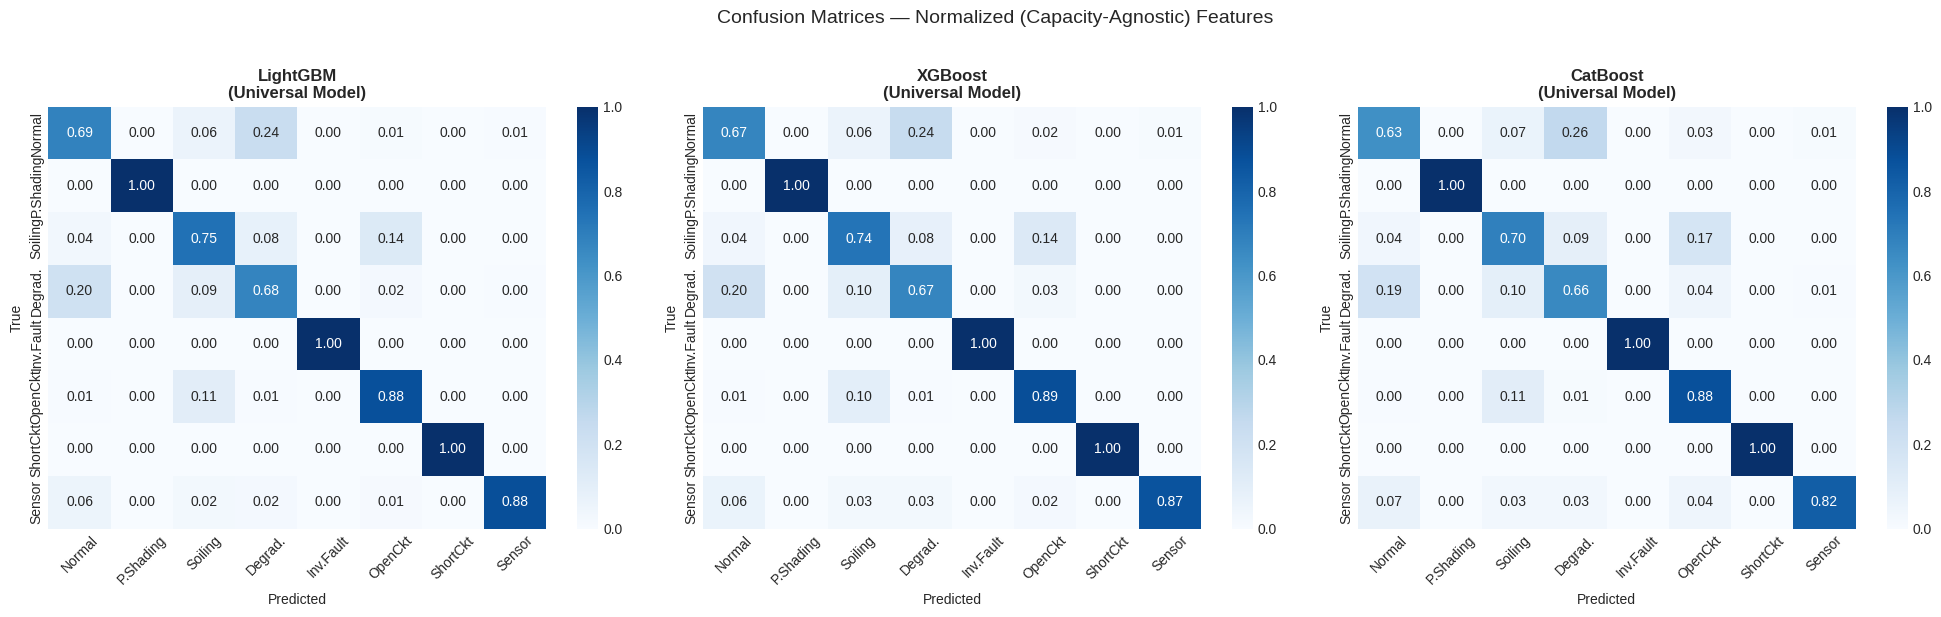

In [12]:
fault_names = [CONFIG['FAULT_LABELS'][i] for i in range(8)]
short_names = ['Normal','P.Shading','Soiling','Degrad.','Inv.Fault','OpenCkt','ShortCkt','Sensor']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, preds) in zip(axes, [
    ('LightGBM', lgb_preds), ('XGBoost', xgb_preds), ('CatBoost', cb_preds)
]):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                xticklabels=short_names, yticklabels=short_names,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{name}\n(Universal Model)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Normalized (Capacity-Agnostic) Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_DIR'], 'confusion_matrices_universal.png'), dpi=120, bbox_inches='tight')
plt.show()


## Step 9 — Feature Importance

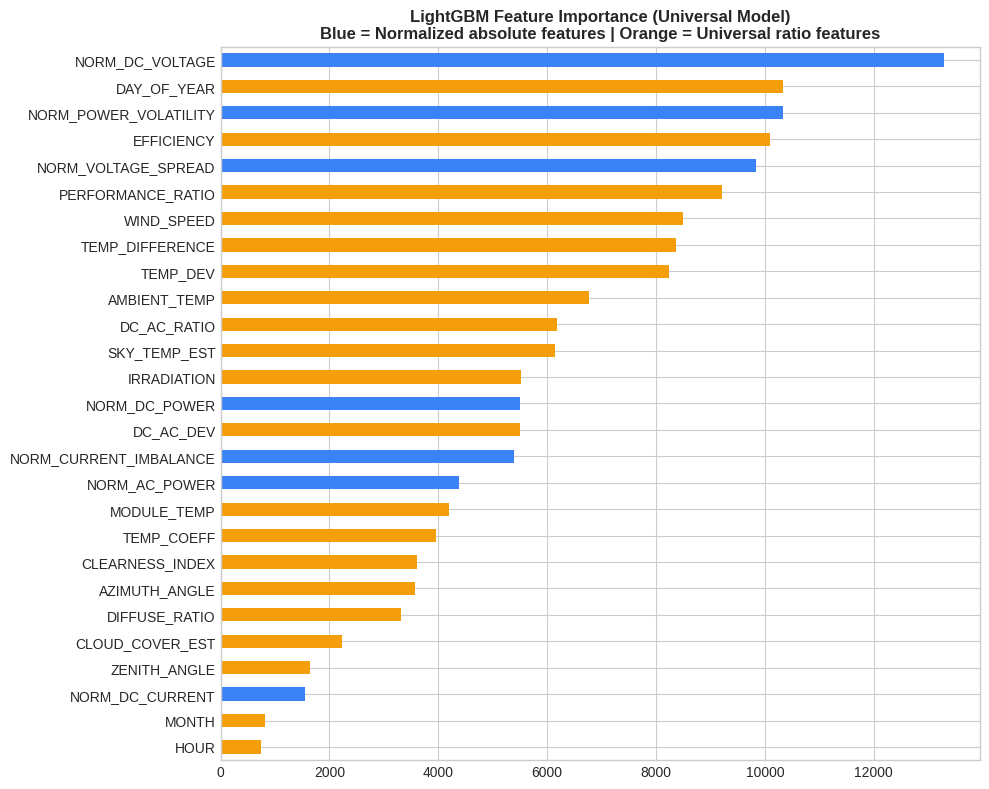

Top 10 features:
   1. [NORM] NORM_DC_VOLTAGE               : 13,287
   2. [UNI ] DAY_OF_YEAR                   : 10,338
   3. [NORM] NORM_POWER_VOLATILITY         : 10,323
   4. [UNI ] EFFICIENCY                    : 10,099
   5. [NORM] NORM_VOLTAGE_SPREAD           : 9,833
   6. [UNI ] PERFORMANCE_RATIO             : 9,218
   7. [UNI ] WIND_SPEED                    : 8,494
   8. [UNI ] TEMP_DIFFERENCE               : 8,364
   9. [UNI ] TEMP_DEV                      : 8,229
  10. [UNI ] AMBIENT_TEMP                  : 6,765


In [13]:
# LightGBM feature importance
lgb_imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#3b82f6' if f.startswith('NORM_') else '#f59e0b' for f in lgb_imp.index]
lgb_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('LightGBM Feature Importance (Universal Model)\n'
             'Blue = Normalized absolute features | Orange = Universal ratio features',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_DIR'], 'feature_importance_universal.png'), dpi=120)
plt.show()
print("Top 10 features:")
for i, (feat, imp) in enumerate(lgb_imp.head(10).items()):
    prefix = "[NORM]" if feat.startswith("NORM_") else "[UNI ]"
    print(f"  {i+1:2d}. {prefix} {feat:<30s}: {imp:,}")


## Step 10 — Save Universal Models & Metadata

In [14]:
model_dir = CONFIG['MODEL_DIR']
os.makedirs(model_dir, exist_ok=True)

# Save models
joblib.dump(lgb_model, os.path.join(model_dir, 'lgb_model.pkl'))
joblib.dump(xgb_model, os.path.join(model_dir, 'xgb_model.pkl'))
joblib.dump(cb_model,  os.path.join(model_dir, 'cb_model.pkl'))

# Save metadata
metadata = {
    "version"         : "universal_v1",
    "description"     : "Capacity-agnostic models. Work on any solar station.",
    "feature_cols"    : FEATURE_COLS,
    "num_features"    : len(FEATURE_COLS),
    "normalized_features": [f for f in FEATURE_COLS if f.startswith("NORM_")],
    "universal_features" : [f for f in FEATURE_COLS if not f.startswith("NORM_")],
    "fault_labels"    : {str(k): v for k, v in CONFIG['FAULT_LABELS'].items()},
    "performance"     : {
        "LightGBM": {"accuracy": round(lgb_acc, 4), "f1": round(lgb_f1, 4)},
        "XGBoost" : {"accuracy": round(xgb_acc, 4), "f1": round(xgb_f1, 4)},
        "CatBoost": {"accuracy": round(cb_acc,  4), "f1": round(cb_f1,  4)},
    },
    "best_model"      : best_model_name,
}

with open(os.path.join(model_dir, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved files in:", model_dir)
for fname in ['lgb_model.pkl', 'xgb_model.pkl', 'cb_model.pkl', 'model_metadata.json']:
    fpath = os.path.join(model_dir, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<30s}: {size_kb:,.0f} KB")

print("\n" + "=" * 60)
print("  TRAINING COMPLETE")
print("  These models are capacity-agnostic and can be deployed")
print("  on any solar station worldwide by normalizing input data.")
print("\n  To deploy on a new station (e.g. 50 kW rooftop):")
print("    1. Set DC_CAPACITY_W = 50_000 in your inference config")
print("    2. Compute NORM_DC_POWER = DC_POWER / 50_000")
print("    3. Feed normalized features to these models")
print("    4. Get fault predictions — no retraining needed!")
print("=" * 60)


Saved files in: /content/drive/MyDrive/SolarGard4/solar_models_universal
  lgb_model.pkl                 : 17,407 KB
  xgb_model.pkl                 : 12,619 KB
  cb_model.pkl                  : 10,254 KB
  model_metadata.json           : 2 KB

  TRAINING COMPLETE
  These models are capacity-agnostic and can be deployed
  on any solar station worldwide by normalizing input data.

  To deploy on a new station (e.g. 50 kW rooftop):
    1. Set DC_CAPACITY_W = 50_000 in your inference config
    2. Compute NORM_DC_POWER = DC_POWER / 50_000
    3. Feed normalized features to these models
    4. Get fault predictions — no retraining needed!


<hr style='border:2px solid #1a73e8'>

# Part 2 — Cross Validation Evaluation
# Comparing 5-Fold Stratified CV with the 80/20 Hold-Out Split above
# This does NOT modify any previous results — it is a separate evaluation.

## Step 11 — 5-Fold Stratified Cross Validation

**Why Cross Validation?**

The 80/20 hold-out split (Step 3) evaluates the model on a single random 20% subset.
Cross Validation rotates through **K different** test sets so that **every sample** is
tested exactly once. This gives:

- A **mean** metric that is more reliable than a single split
- A **standard deviation** that shows how stable the model is across different data splits
- Less dependence on the randomness of `train_test_split`

We use **StratifiedKFold** to preserve the class balance (each fault type ~12.5%) in every fold.

In [15]:
# ================================================================
# 5-FOLD STRATIFIED CROSS VALIDATION
# Uses the SAME X, y from Step 3 (no re-splitting needed)
# ================================================================

from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print('=' * 60)
print(f'  5-FOLD STRATIFIED CROSS VALIDATION')
print(f'  Dataset : {len(X):,} samples, {X.shape[1]} features')
print(f'  Folds   : {N_SPLITS}')
print('=' * 60)

# ── Define fresh model factories (same hyperparameters as Steps 4-6) ──
def make_lgb():
    return lgb.LGBMClassifier(
        objective='multiclass', num_class=8, metric='multi_logloss',
        learning_rate=0.05, n_estimators=500,
        num_leaves=63, max_depth=8, min_child_samples=20,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        lambda_l1=0.1, lambda_l2=0.1, verbose=-1, random_state=42,
    )

def make_xgb():
    return xgb.XGBClassifier(
        objective='multi:softprob', num_class=8,
        learning_rate=0.05, n_estimators=500,
        max_depth=7, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, eval_metric='mlogloss',
        early_stopping_rounds=50, verbosity=0,
    )

def make_cb():
    return CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, random_seed=42,
        loss_function='MultiClass', eval_metric='Accuracy',
        early_stopping_rounds=50, verbose=0,
    )

model_factories = {
    'LightGBM': make_lgb,
    'XGBoost' : make_xgb,
    'CatBoost': make_cb,
}

# ── Run Cross Validation ──
cv_results = {}

for name, factory in model_factories.items():
    print(f'\n--- {name} ---')
    fold_accs = []
    fold_f1s  = []
    fold_reports = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model = factory()

        # LightGBM & XGBoost: use a small validation slice for early stopping
        if name == 'LightGBM':
            # Split 10% of training for early-stopping eval
            es_split = max(1, int(len(X_tr) * 0.1))
            model.fit(
                X_tr[:-es_split], y_tr[:-es_split],
                eval_set=[(X_tr[-es_split:], y_tr[-es_split:])],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
            )
        elif name == 'XGBoost':
            es_split = max(1, int(len(X_tr) * 0.1))
            model.fit(
                X_tr[:-es_split], y_tr[:-es_split],
                eval_set=[(X_tr[-es_split:], y_tr[-es_split:])],
                verbose=False
            )
        elif name == 'CatBoost':
            es_split = max(1, int(len(X_tr) * 0.1))
            model.fit(
                X_tr[:-es_split], y_tr[:-es_split],
                eval_set=(X_tr[-es_split:], y_tr[-es_split:]),
                use_best_model=True
            )

        preds = model.predict(X_te)
        if name == 'CatBoost':
            preds = preds.flatten()

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='weighted')
        fold_accs.append(acc)
        fold_f1s.append(f1)

        print(f'  Fold {fold_idx+1}/{N_SPLITS}: Accuracy={acc*100:.2f}%  F1={f1*100:.2f}%')

    cv_results[name] = {
        'acc_mean': np.mean(fold_accs),
        'acc_std' : np.std(fold_accs),
        'f1_mean' : np.mean(fold_f1s),
        'f1_std'  : np.std(fold_f1s),
        'fold_accs': fold_accs,
        'fold_f1s' : fold_f1s,
    }

print('\n' + '=' * 60)
print('  CROSS VALIDATION SUMMARY')
print('=' * 60)
print(f"  {'Model':<12} {'Acc Mean':>10} {'Acc Std':>10} {'F1 Mean':>10} {'F1 Std':>10}")
print('-' * 60)
for name, r in cv_results.items():
    print(f"  {name:<12} {r['acc_mean']*100:>9.2f}% {r['acc_std']*100:>9.2f}% "
          f"{r['f1_mean']*100:>9.2f}% {r['f1_std']*100:>9.2f}%")
print('=' * 60)

  5-FOLD STRATIFIED CROSS VALIDATION
  Dataset : 80,941 samples, 27 features
  Folds   : 5

--- LightGBM ---
  Fold 1/5: Accuracy=85.05%  F1=85.14%
  Fold 2/5: Accuracy=85.32%  F1=85.41%
  Fold 3/5: Accuracy=85.61%  F1=85.71%
  Fold 4/5: Accuracy=85.42%  F1=85.52%
  Fold 5/5: Accuracy=85.25%  F1=85.35%

--- XGBoost ---
  Fold 1/5: Accuracy=85.20%  F1=85.29%
  Fold 2/5: Accuracy=85.46%  F1=85.52%
  Fold 3/5: Accuracy=85.61%  F1=85.70%
  Fold 4/5: Accuracy=85.15%  F1=85.25%
  Fold 5/5: Accuracy=85.45%  F1=85.53%

--- CatBoost ---
  Fold 1/5: Accuracy=83.62%  F1=83.73%
  Fold 2/5: Accuracy=82.62%  F1=82.70%
  Fold 3/5: Accuracy=82.07%  F1=82.17%
  Fold 4/5: Accuracy=83.78%  F1=83.87%
  Fold 5/5: Accuracy=83.20%  F1=83.29%

  CROSS VALIDATION SUMMARY
  Model          Acc Mean    Acc Std    F1 Mean     F1 Std
------------------------------------------------------------
  LightGBM         85.33%      0.18%     85.43%      0.19%
  XGBoost          85.37%      0.17%     85.46%      0.17%
  Cat

## Step 12 — Per-Fold Classification Report (Best CV Model)

Re-train the best model from CV and print a detailed classification report for each fold
so we can see per-class performance across different data splits.

In [16]:
# Identify best CV model
cv_best_name = max(cv_results, key=lambda k: cv_results[k]['f1_mean'])
print(f'Best CV model: {cv_best_name}')
print(f'  Mean F1: {cv_results[cv_best_name]["f1_mean"]*100:.2f}% (+/- {cv_results[cv_best_name]["f1_std"]*100:.2f}%)')
print(f'  Mean Accuracy: {cv_results[cv_best_name]["acc_mean"]*100:.2f}% (+/- {cv_results[cv_best_name]["acc_std"]*100:.2f}%)')

# Re-run with classification reports
print(f'\n{"="*60}')
print(f'  DETAILED CLASSIFICATION REPORTS — {cv_best_name} (5-Fold CV)')
print(f'{"="*60}')

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    model = model_factories[cv_best_name]()
    es_split = max(1, int(len(X_tr) * 0.1))

    if cv_best_name == 'LightGBM':
        model.fit(X_tr[:-es_split], y_tr[:-es_split],
                  eval_set=[(X_tr[-es_split:], y_tr[-es_split:])],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    elif cv_best_name == 'XGBoost':
        model.fit(X_tr[:-es_split], y_tr[:-es_split],
                  eval_set=[(X_tr[-es_split:], y_tr[-es_split:])], verbose=False)
    elif cv_best_name == 'CatBoost':
        model.fit(X_tr[:-es_split], y_tr[:-es_split],
                  eval_set=(X_tr[-es_split:], y_tr[-es_split:]), use_best_model=True)

    preds = model.predict(X_te)
    if cv_best_name == 'CatBoost':
        preds = preds.flatten()

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='weighted')
    print(f'\n--- Fold {fold_idx+1}: Accuracy={acc*100:.2f}%  F1={f1*100:.2f}% ---')
    print(classification_report(y_te, preds,
          target_names=[CONFIG['FAULT_LABELS'][i] for i in range(8)]))


Best CV model: XGBoost
  Mean F1: 85.46% (+/- 0.17%)
  Mean Accuracy: 85.37% (+/- 0.17%)

  DETAILED CLASSIFICATION REPORTS — XGBoost (5-Fold CV)

--- Fold 1: Accuracy=85.20%  F1=85.29% ---
                     precision    recall  f1-score   support

             Normal       0.70      0.66      0.68      2025
    Partial Shading       0.99      1.00      1.00      2023
            Soiling       0.70      0.73      0.72      2024
        Degradation       0.65      0.69      0.67      2023
     Inverter Fault       1.00      1.00      1.00      2024
Open-Circuit String       0.81      0.86      0.83      2023
      Short-Circuit       1.00      1.00      1.00      2023
       Sensor Fault       0.98      0.88      0.93      2024

           accuracy                           0.85     16189
          macro avg       0.86      0.85      0.85     16189
       weighted avg       0.86      0.85      0.85     16189


--- Fold 2: Accuracy=85.46%  F1=85.52% ---
                     precision 

## Step 13 — Comparison: 80/20 Hold-Out vs 5-Fold Cross Validation

Now we compare the two evaluation strategies side by side.
- **80/20 Split**: single random split, one evaluation (from Steps 3-7)
- **5-Fold CV**: 5 different splits, mean &plusmn; std (from Steps 11-12)

In [17]:
# ================================================================
# COMPARISON TABLE: 80/20 Hold-Out vs 5-Fold Cross Validation
# ================================================================

split_results = {
    'LightGBM': {'accuracy': lgb_acc, 'f1': lgb_f1},
    'XGBoost' : {'accuracy': xgb_acc, 'f1': xgb_f1},
    'CatBoost': {'accuracy': cb_acc,  'f1': cb_f1},
}

print('=' * 80)
print('  COMPARISON: 80/20 HOLD-OUT SPLIT vs 5-FOLD CROSS VALIDATION')
print('=' * 80)
print(f"  {'Model':<12} │ {'80/20 Acc':>10} │ {'CV Acc Mean':>12} │ {'CV Acc Std':>10} │ {'80/20 F1':>10} │ {'CV F1 Mean':>12} │ {'CV F1 Std':>10}")
print('  ' + '─' * 78)

for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    s = split_results[name]
    c = cv_results[name]
    print(f"  {name:<12} │ {s['accuracy']*100:>9.2f}% │ {c['acc_mean']*100:>10.2f}% │ {c['acc_std']*100:>9.2f}% │ {s['f1']*100:>9.2f}% │ {c['f1_mean']*100:>10.2f}% │ {c['f1_std']*100:>9.2f}%")

print('=' * 80)

# Determine which evaluation method gives more reliable results
print('\n  Key Observations:')
for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    s = split_results[name]
    c = cv_results[name]
    diff_acc = (s['accuracy'] - c['acc_mean']) * 100
    diff_f1  = (s['f1'] - c['f1_mean']) * 100
    print(f'  - {name}: 80/20 accuracy is {diff_acc:+.2f}% vs CV mean;'
          f' CV std = {c["acc_std"]*100:.2f}% (model stability)')

print('\n  Interpretation:')
print('  • If CV mean ≈ 80/20 accuracy → the single split was representative')
print('  • If CV mean < 80/20 accuracy → the single split may have been optimistic')
print('  • Low CV std → model is stable across different data splits')
print('  • High CV std → model performance varies; more data or tuning may help')
print('  • Cross Validation is more reliable because it uses ALL data for testing')

  COMPARISON: 80/20 HOLD-OUT SPLIT vs 5-FOLD CROSS VALIDATION
  Model        │  80/20 Acc │  CV Acc Mean │ CV Acc Std │   80/20 F1 │   CV F1 Mean │  CV F1 Std
  ──────────────────────────────────────────────────────────────────────────────
  LightGBM     │     85.89% │      85.33% │      0.18% │     85.98% │      85.43% │      0.19%
  XGBoost      │     85.40% │      85.37% │      0.17% │     85.48% │      85.46% │      0.17%
  CatBoost     │     83.51% │      83.06% │      0.64% │     83.58% │      83.15% │      0.64%

  Key Observations:
  - LightGBM: 80/20 accuracy is +0.55% vs CV mean; CV std = 0.18% (model stability)
  - XGBoost: 80/20 accuracy is +0.03% vs CV mean; CV std = 0.17% (model stability)
  - CatBoost: 80/20 accuracy is +0.45% vs CV mean; CV std = 0.64% (model stability)

  Interpretation:
  • If CV mean ≈ 80/20 accuracy → the single split was representative
  • If CV mean < 80/20 accuracy → the single split may have been optimistic
  • Low CV std → model is stable acros

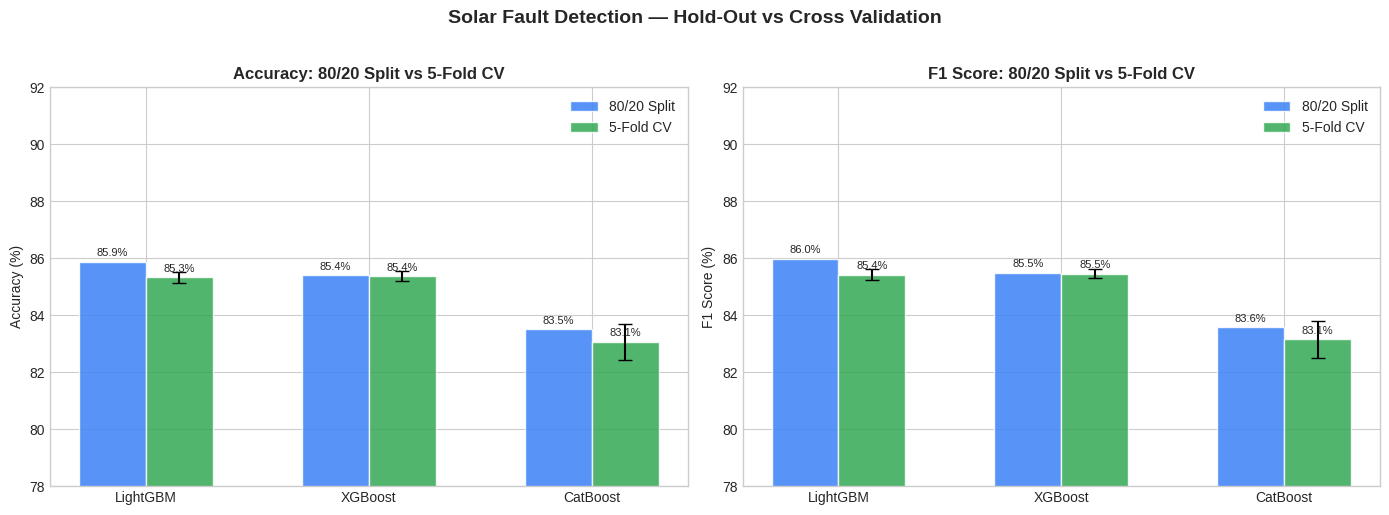

Saved: split_vs_cv_comparison.png


In [18]:
# ================================================================
# VISUAL COMPARISON: Grouped Bar Chart
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = ['LightGBM', 'XGBoost', 'CatBoost']
x = np.arange(len(model_names))
width = 0.3

# ── Accuracy Comparison ──
split_accs  = [split_results[m]['accuracy'] * 100 for m in model_names]
cv_acc_means = [cv_results[m]['acc_mean'] * 100 for m in model_names]
cv_acc_stds  = [cv_results[m]['acc_std'] * 100 for m in model_names]

bars1 = axes[0].bar(x - width/2, split_accs, width, label='80/20 Split',
                     color='#3b82f6', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + width/2, cv_acc_means, width, yerr=cv_acc_stds,
                     capsize=5, label='5-Fold CV',
                     color='#34a853', alpha=0.85, edgecolor='white')

axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy: 80/20 Split vs 5-Fold CV', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend(loc='best')
axes[0].set_ylim(78, 92)
for b in list(bars1) + list(bars2):
    axes[0].annotate(f'{b.get_height():.1f}%',
                     xy=(b.get_x() + b.get_width()/2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8)

# ── F1 Score Comparison ──
split_f1s   = [split_results[m]['f1'] * 100 for m in model_names]
cv_f1_means = [cv_results[m]['f1_mean'] * 100 for m in model_names]
cv_f1_stds  = [cv_results[m]['f1_std'] * 100 for m in model_names]

bars3 = axes[1].bar(x - width/2, split_f1s, width, label='80/20 Split',
                     color='#3b82f6', alpha=0.85, edgecolor='white')
bars4 = axes[1].bar(x + width/2, cv_f1_means, width, yerr=cv_f1_stds,
                     capsize=5, label='5-Fold CV',
                     color='#34a853', alpha=0.85, edgecolor='white')

axes[1].set_ylabel('F1 Score (%)')
axes[1].set_title('F1 Score: 80/20 Split vs 5-Fold CV', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].legend(loc='best')
axes[1].set_ylim(78, 92)
for b in list(bars3) + list(bars4):
    axes[1].annotate(f'{b.get_height():.1f}%',
                     xy=(b.get_x() + b.get_width()/2, b.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8)

plt.suptitle('Solar Fault Detection — Hold-Out vs Cross Validation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['MODEL_DIR'], 'split_vs_cv_comparison.png'), dpi=150)
plt.show()
print('Saved: split_vs_cv_comparison.png')

## Step 15 — Final Verdict: Which Evaluation is Better?

| Criterion | 80/20 Hold-Out | 5-Fold CV |
|---|---|---|
| **Reliability** | Single random split | 5 different splits, averaged |
| **Data usage** | Only 20% tested | Every sample tested once |
| **Variance info** | Not available | Std dev across folds |
| **Speed** | Fast (1 training) | Slower (5 trainings) |
| **Overfitting detection** | Limited | Better (fold variance reveals it) |
| **Research standard** | Basic | Gold standard |

**Conclusion:** Cross Validation provides a **more reliable and trustworthy** evaluation
because it reduces the impact of random data splitting. The mean accuracy from CV
represents the model's true generalization ability better than a single hold-out test.
However, the 80/20 split remains useful for final model training and deployment.

In [20]:
# ================================================================
# SAVE CV RESULTS TO METADATA
# ================================================================

# Update metadata with CV results
metadata['cv_performance'] = {
    name: {
        'cv_accuracy_mean': round(r['acc_mean'], 4),
        'cv_accuracy_std' : round(r['acc_std'], 4),
        'cv_f1_mean'      : round(r['f1_mean'], 4),
        'cv_f1_std'       : round(r['f1_std'], 4),
    }
    for name, r in cv_results.items()
}
metadata['evaluation_method'] = '5-fold stratified cross validation + 80/20 hold-out'
metadata['cv_best_model'] = cv_best_name

with open(os.path.join(model_dir, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('Updated model_metadata.json with CV results.')
print('\n' + '=' * 60)
print('  CROSS VALIDATION EVALUATION COMPLETE')
print('=' * 60)
print(f'  Best model (80/20):   {best_model_name}')
print(f'  Best model (CV):      {cv_best_name}')
print(f'  CV Accuracy:          {cv_results[cv_best_name]["acc_mean"]*100:.2f}% (+/- {cv_results[cv_best_name]["acc_std"]*100:.2f}%)')
print(f'  CV F1 Score:          {cv_results[cv_best_name]["f1_mean"]*100:.2f}% (+/- {cv_results[cv_best_name]["f1_std"]*100:.2f}%)')
print('=' * 60)

Updated model_metadata.json with CV results.

  CROSS VALIDATION EVALUATION COMPLETE
  Best model (80/20):   LightGBM
  Best model (CV):      XGBoost
  CV Accuracy:          85.37% (+/- 0.17%)
  CV F1 Score:          85.46% (+/- 0.17%)
